# Route Visualization

This notebook provides a general function to visualize actual routes taken by a vehicle.

## Features
- Visualize the sequence of stations visited
- Display actions performed at each station (Load/Unload/Maintenance)
- Optional background map overlay
- Configurable colors and styling

In [2]:
import re
import json
import matplotlib.pyplot as plt

THESIS_COLORS = {
    "Pale Fern": "#D9E5D6",
    "Sage Green": "#84A579",
    "Dark Spruce": "#344E41",
    "Warm Red": "#D1495B",
    "Ochre Gold": "#EDAE49",
    "Blue Accent": "#526ECA",
    "Mist Grey": "#E6E6E6",
}

In [3]:
def load_station_coordinates(json_filepath):
    """
    Load station coordinates from JSON (keeps lat/lon format).
    Returns: dict mapping station_id to {lat, lon} coordinates
    """
    with open(json_filepath, 'r') as f:
        data = json.load(f)
    
    station_coords = {}
    
    for station in data['stations']:
        station_id = str(station['id'])
        lat = station['location'][0]
        lon = station['location'][1]
        station_coords[station_id] = {'lat': lat, 'lon': lon}
    
    return station_coords

print("load_station_coordinates() function defined")

load_station_coordinates() function defined


In [4]:
def visualize_actual_route(routing_data, station_coords, map_image_path=None):
    """
    Visualize the actual route taken (sequence of stations visited).
    
    Parameters:
    -----------
    routing_data : list of dict
        List of routing stops, each containing:
        - 'current_station': str, station ID
        - 'actions': list of str, actions performed at this station
        
        Example:
        [
            {'current_station': '5', 'actions': ['Load: 2', 'Unload: 1']},
            {'current_station': '12', 'actions': ['Maint: 5m']},
            {'current_station': '8', 'actions': []}
        ]
    
    station_coords : dict
        Station coordinates mapping station_id to {'lat': float, 'lon': float}
        
        Example:
        {
            '5': {'lat': 63.4102, 'lon': 10.3985},
            '12': {'lat': 63.4125, 'lon': 10.4012}
        }
    
    map_image_path : str, optional
        Path to background map image (PNG/JPG/SVG). Set to None for no background.
    """
    fig, ax = plt.subplots(figsize=(18, 14), facecolor='white')
    
    # Determine bounds from station coordinates
    if station_coords:
        lons = [coord['lon'] for coord in station_coords.values()]
        lats = [coord['lat'] for coord in station_coords.values()]
        lon_min, lon_max = min(lons), max(lons)
        lat_min, lat_max = min(lats), max(lats)
        
        # Add padding
        lon_margin = (lon_max - lon_min) * 0.1
        lat_margin = (lat_max - lat_min) * 0.1
        
        ax.set_xlim(lon_min - lon_margin, lon_max + lon_margin)
        ax.set_ylim(lat_min - lat_margin, lat_max + lat_margin)
    
    # Add background map if provided
    if map_image_path:
        try:
            img = plt.imread(map_image_path)
            # Use current axis limits for extent
            extent = [ax.get_xlim()[0], ax.get_xlim()[1], 
                     ax.get_ylim()[0], ax.get_ylim()[1]]
            ax.imshow(img, extent=extent, aspect='auto', alpha=0.65)
        except Exception as e:
            print(f"Warning: Could not load map image: {e}")
            ax.grid(True, alpha=0.3, linestyle='--', color='gray')
            ax.set_facecolor('#f8f9fa')
    else:
        ax.grid(True, alpha=0.3, linestyle='--', color='gray')
        ax.set_facecolor('#f8f9fa')
    
    ax.set_xlabel('Longitude', fontsize=13, fontweight='semibold')
    ax.set_ylabel('Latitude', fontsize=13, fontweight='semibold')
    ax.set_title('Actual Route Taken', fontsize=22, 
                 color=THESIS_COLORS["Dark Spruce"], fontweight='bold', pad=20)
    
    lat_offset = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.015  # Dynamic offset
    
    # First pass: Draw all arrows (so they're underneath)
    for i, block in enumerate(routing_data):
        if i >= len(routing_data) - 1:
            continue
            
        current_id = block['current_station']
        next_id = routing_data[i + 1]['current_station']
        
        if current_id not in station_coords or next_id not in station_coords:
            continue
        if current_id == next_id:
            continue
            
        lon = station_coords[current_id]['lon']
        lat = station_coords[current_id]['lat']
        next_lon = station_coords[next_id]['lon']
        next_lat = station_coords[next_id]['lat']
        
        # Draw shadow arrow
        ax.annotate("", xy=(next_lon, next_lat), xytext=(lon, lat),
                    arrowprops=dict(arrowstyle="->", lw=5,
                                    color='black', alpha=0.15))
        
        # Draw main arrow
        ax.annotate("", xy=(next_lon, next_lat), xytext=(lon, lat),
                    arrowprops=dict(arrowstyle="->", lw=3.5,
                                    color=THESIS_COLORS["Ochre Gold"],
                                    alpha=0.9))
        
        # Add sequence number with shadow
        mid_lon = (lon + next_lon) / 2
        mid_lat = (lat + next_lat) / 2
        offset = (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.001
        # Shadow
        ax.text(mid_lon + offset, mid_lat - offset, str(i+1), 
                color='black', weight='bold', fontsize=11, alpha=0.3,
                ha='center', va='center', zorder=5)
        # Main text
        ax.text(mid_lon, mid_lat, str(i+1), color=THESIS_COLORS["Warm Red"], 
                weight='bold', fontsize=11, ha='center', va='center',
                bbox={'facecolor': 'white', 'edgecolor': THESIS_COLORS["Ochre Gold"], 
                      'linewidth': 1.5, 'alpha': 0.95, 'pad': 0.5, 'boxstyle': 'circle'},
                zorder=6)
    
    # Second pass: Plot stations and actions (on top)
    for i, block in enumerate(routing_data):
        current_id = block['current_station']
        
        if current_id not in station_coords:
            continue
        
        lon = station_coords[current_id]['lon']
        lat = station_coords[current_id]['lat']
        offset = (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.001
        
        # Plot station marker shadow
        ax.text(lon + offset, lat - offset, f"S{current_id}", 
                color='black', weight='bold', fontsize=13, alpha=0.3,
                ha='center', va='center', zorder=9)
        
        # Plot station marker
        ax.text(lon, lat, f"S{current_id}", color="white", weight='bold', fontsize=13,
                ha='center', va='center',
                bbox={'facecolor': THESIS_COLORS["Blue Accent"], 
                      'edgecolor': 'none', 
                      'linewidth': 0,
                      'boxstyle':'round,pad=0.5'},
                zorder=10)
        
        # Plot actions
        if block['actions']:
            action_text = "\n".join(block['actions'])
            # Shadow
            ax.text(lon + offset, lat - lat_offset - offset, action_text, 
                    fontsize=10, color='black', alpha=0.2,
                    verticalalignment='top', horizontalalignment='center', zorder=7)
            # Main text
            ax.text(lon, lat - lat_offset, action_text, fontsize=10,
                    verticalalignment='top', horizontalalignment='center',
                    bbox={'facecolor': THESIS_COLORS["Mist Grey"], 
                          'edgecolor': '#AAAAAA', 
                          'linewidth': 1.5,
                          'boxstyle': 'round,pad=0.6',
                          'alpha': 0.95},
                    zorder=8)
    
    plt.tight_layout()
    plt.savefig('actual_route.svg', format='svg', bbox_inches='tight')
    plt.show()

print("visualize_actual_route() function defined")

visualize_actual_route() function defined


## Required Data Format

### 1. Routing Data (`routing_data`)

A **list of dictionaries**, where each dictionary represents a stop on the route:

```python
routing_data = [
    {
        'current_station': '5',      # Station ID (string)
        'actions': [                  # List of action strings (can be empty)
            'Load: 2',
            'Unload: 1',
            'Maint: 5m'
        ]
    },
    {
        'current_station': '12',
        'actions': ['Load: 3']
    },
    {
        'current_station': '8',
        'actions': []  # No actions at this station
    }
]
```

**Requirements:**
- `current_station`: String representing the station ID
- `actions`: List of strings describing actions (Load/Unload/Maintenance)
  - Can be any descriptive text (e.g., "Load: 2", "Unload: 3 bikes", "Maintenance: 10 min")
  - Can be an empty list if no actions performed

### 2. Station Coordinates (`station_coords`)

A **dictionary** mapping station IDs to latitude/longitude coordinates:

```python
station_coords = {
    '5': {'lat': 63.4102, 'lon': 10.3985},
    '12': {'lat': 63.4125, 'lon': 10.4012},
    '8': {'lat': 63.4088, 'lon': 10.3956}
}
```

**Requirements:**
- Keys: Station IDs as strings (must match `current_station` values in routing_data)
- Values: Dictionary with `'lat'` and `'lon'` keys containing float coordinates

**Note:** Station coordinates can be loaded from a JSON file using the `load_station_coordinates()` function (see below).

In [5]:
## Load Station Coordinates from JSON

The JSON file should have the following structure:

```json
{
  "stations": [
    {
      "id": 5,
      "location": [63.4102, 10.3985]
    },
    {
      "id": 12,
      "location": [63.4125, 10.4012]
    }
  ]
}
```

Where `location` is `[latitude, longitude]`.

SyntaxError: invalid syntax (2777467656.py, line 3)

In [ ]:
# Example: Load station coordinates from your JSON file
json_file = r'C:\Users\ingvivsu\OneDrive - NTNU\Master\FOMOsim\policies\sjovik_sund\output\instance_data\TD_W34_67.json'
station_coords = load_station_coordinates(json_file)
print(f"Loaded {len(station_coords)} station coordinates")

## Create Your Routing Data

Build your routing data according to the format specified above.

In [ ]:
# Example: Manually create routing data
routing_data = [
    {
        'current_station': '5',
        'actions': ['Load: 2', 'Unload: 1']
    },
    {
        'current_station': '12',
        'actions': ['Unload: 3']
    },
    {
        'current_station': '8',
        'actions': ['Load: 4', 'Maint: 10m']
    },
    {
        'current_station': '15',
        'actions': []
    }
]

# OR: Parse from your own file format
# routing_data = your_custom_parsing_function('your_file.txt')

## Visualize the Route

Call the visualization function with your data.

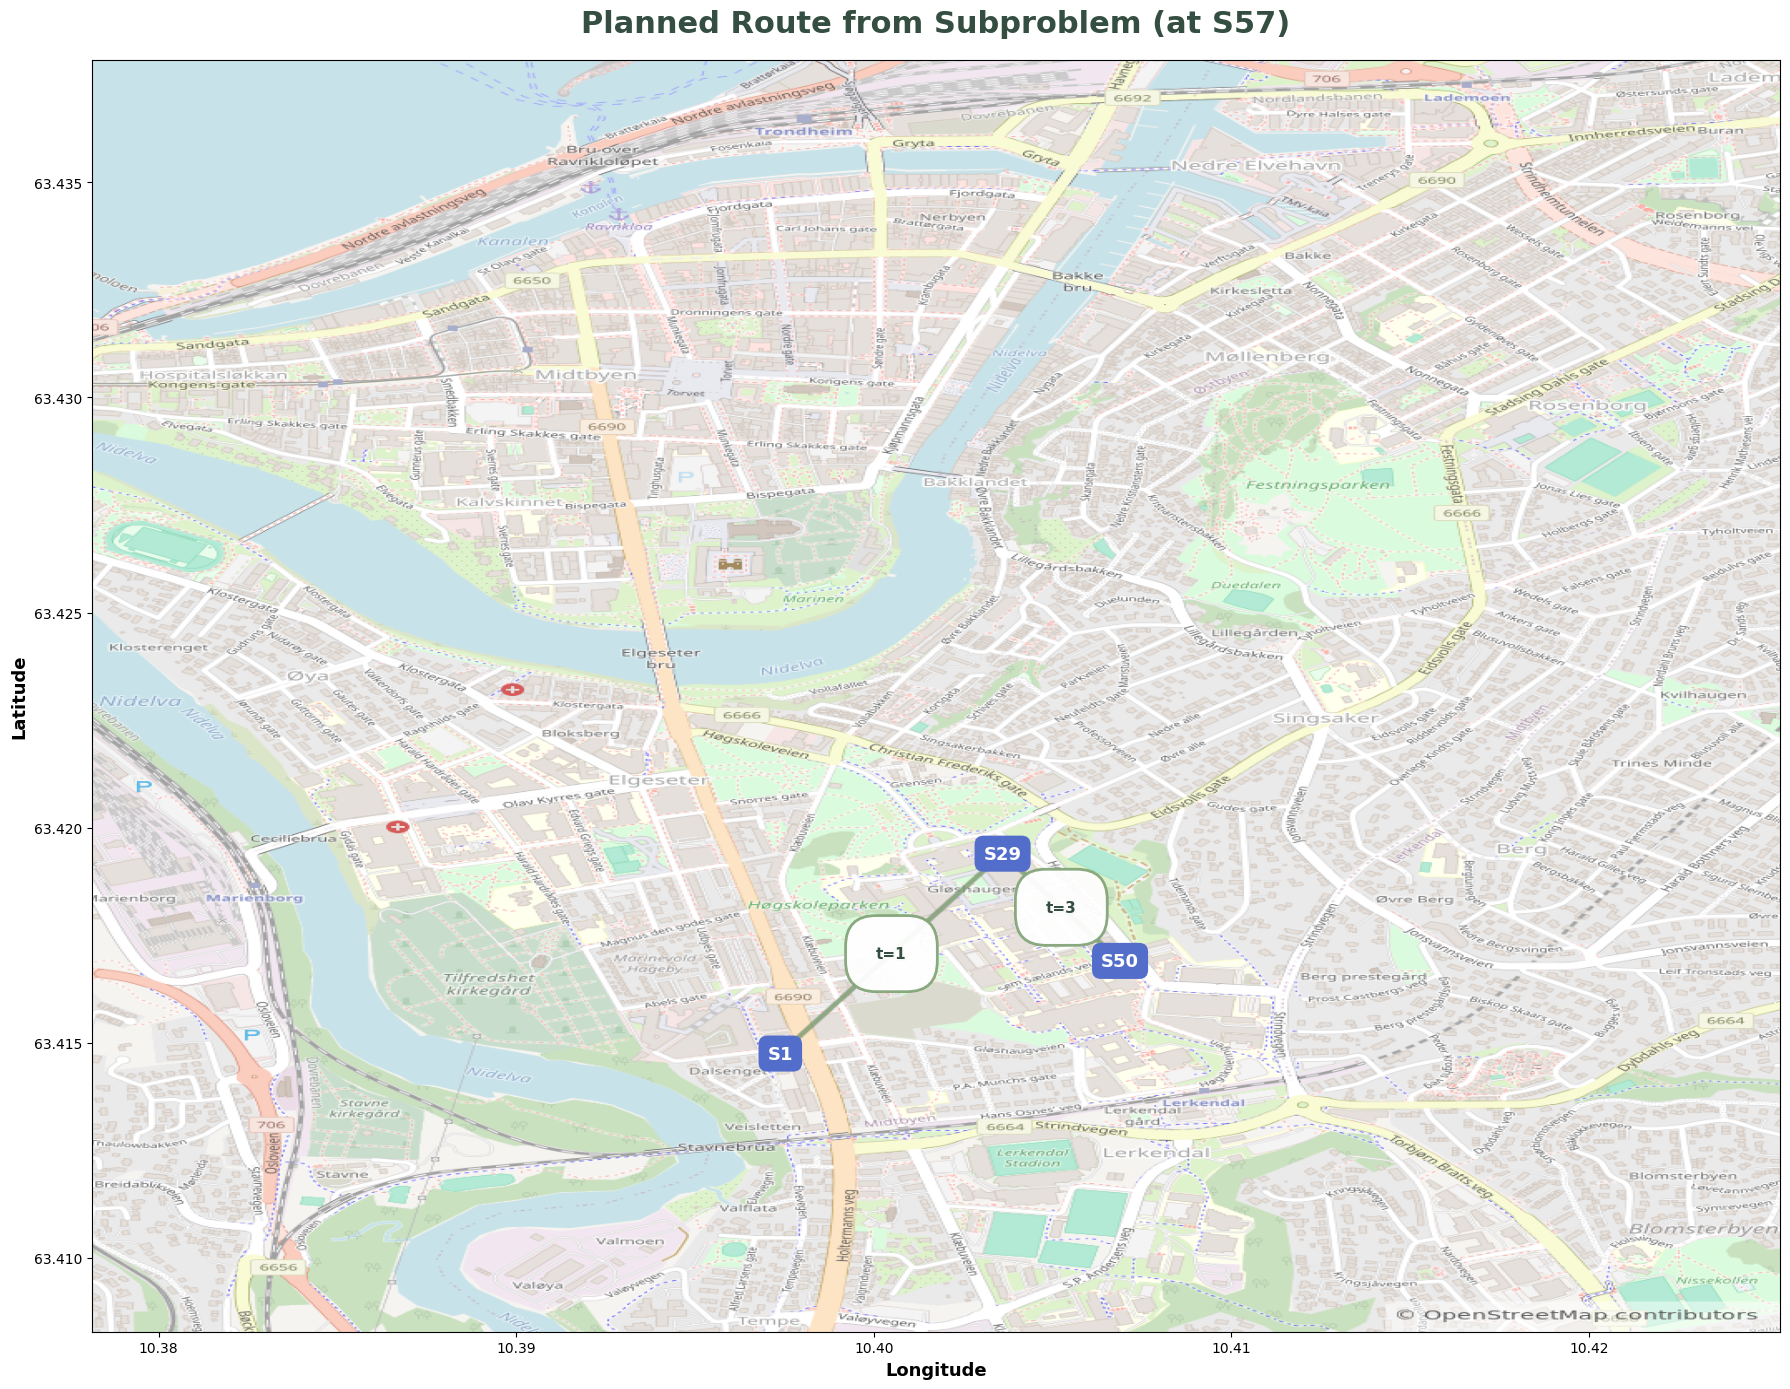

In [ ]:
# Visualize the route
# Optional: Specify a map image path, or set to None for no background
map_path = r'C:\Users\ingvivsu\OneDrive - NTNU\Master\FOMOsim\policies\sjovik_sund\Scripts\map (1).png'

visualize_actual_route(routing_data, station_coords, map_image_path=map_path)